# Bangladesh Climate Change Analysis

## A Comprehensive Data Science Study of Temperature and Rainfall Trends

---

### Author

Md. Miraj-Ul-Islam

### Dataset

Bangladesh Temperature & Rainfall Dataset

### Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Plotly
- Scikit-Learn
- Statsmodels

---

## Objectives

This project investigates long-term climate patterns in Bangladesh using historical temperature and rainfall data.

The analysis focuses on:

- Climate change trends
- Rainfall variability
- Temperature anomalies
- Seasonal patterns
- Extreme weather events
- Statistical analysis
- Machine Learning prediction
- Time-series forecasting

In [19]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from matplotlib.ticker import MaxNLocator

import plotly.express as px
import plotly.graph_objects as go

from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format","{:.2f}".format)

In [20]:
df = pd.read_csv(r"C:\Users\USER\Downloads\Bangladesh weather data analysis\sorted_temp_and_rain_dataset.csv")

df.head()

,tem,Month,Year,rain
0,16.98,1,1901,18.54
1,19.90,2,1901,16.25
2,24.32,3,1901,70.80
3,28.18,4,1901,66.16
4,27.89,5,1901,267.21


In [21]:
print("Shape:", df.shape)

df.head()

Shape: (1474, 4)


,tem,Month,Year,rain
0,16.98,1,1901,18.54
1,19.90,2,1901,16.25
2,24.32,3,1901,70.80
3,28.18,4,1901,66.16
4,27.89,5,1901,267.21


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1474 entries, 0 to 1473
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tem     1474 non-null   float64
 1   Month   1474 non-null   int64  
 2   Year    1474 non-null   int64  
 3   rain    1474 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 46.2 KB


In [22]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
tem,1474.00,25.07,3.70,15.93,22.12,27.01,28.03,29.53
Month,1474.00,6.49,3.45,1.00,3.25,6.00,9.00,12.00
Year,1474.00,1961.92,35.47,1901.00,1931.00,1962.00,1993.00,2023.00
rain,1474.00,202.82,200.78,0.00,19.38,146.41,347.57,1012.02


In [7]:
df.isnull().sum()

tem      0
Month    0
Year     0
rain     0
dtype: int64

In [23]:
df.duplicated().sum()

np.int64(0)

In [25]:
df.rename(columns={
    "tem":"Temperature",
    "rain":"Rainfall"
}, inplace=True)

In [26]:
df.dtypes

Temperature    float64
Month            int64
Year             int64
Rainfall       float64
dtype: object

In [27]:
quality = pd.DataFrame({
    "Column":df.columns,
    "Missing":df.isna().sum().values,
    "Unique":df.nunique().values,
    "Datatype":df.dtypes.values
})

quality

,Column,Missing,Unique,Datatype
0,Temperature,0,1460,float64
1,Month,0,12,int64
2,Year,0,123,int64
3,Rainfall,0,1473,float64


## Initial Findings

- Dataset successfully loaded.
- No duplicated rows detected.
- Temperature and rainfall columns are numerical.
- Monthly observations are available.
- Dataset is ready for exploratory analysis.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the underlying structure of the dataset before applying statistical methods or machine learning models.

In this section, we explore:

- Temperature distribution
- Rainfall distribution
- Monthly climate patterns
- Long-term climate trends
- Relationships between variables

In [28]:
print("="*50)
print("Dataset Shape")
print("="*50)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\nColumns")

for col in df.columns:
    print("-", col)

Dataset Shape
Rows    : 1474
Columns : 4

Columns
- Temperature
- Month
- Year
- Rainfall


In [29]:
stats_summary = df.describe().T

stats_summary["Range"] = stats_summary["max"] - stats_summary["min"]

stats_summary["Coefficient of Variation (%)"] = (
    stats_summary["std"]/stats_summary["mean"]*100
)

stats_summary.round(2)

,count,mean,std,min,25%,50%,75%,max,Range,Coefficient of Variation (%)
Temperature,1474.00,25.07,3.70,15.93,22.12,27.01,28.03,29.53,13.60,14.77
Month,1474.00,6.49,3.45,1.00,3.25,6.00,9.00,12.00,11.00,53.14
Year,1474.00,1961.92,35.47,1901.00,1931.00,1962.00,1993.00,2023.00,122.00,1.81
Rainfall,1474.00,202.82,200.78,0.00,19.38,146.41,347.57,1012.02,1012.02,99.00


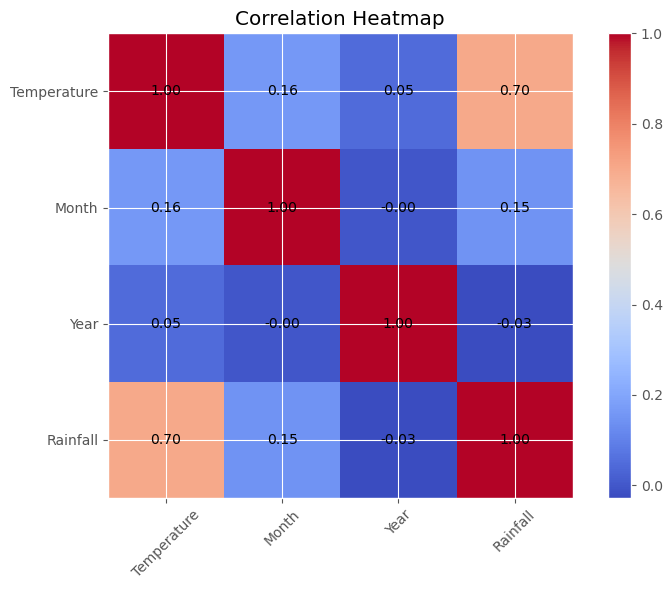

In [30]:
import matplotlib.pyplot as plt

corr = df.select_dtypes(include=np.number).corr()

fig, ax = plt.subplots(figsize=(8,6))

im = ax.imshow(corr, cmap="coolwarm")

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))

ax.set_xticklabels(corr.columns, rotation=45)
ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i,
                f"{corr.iloc[i,j]:.2f}",
                ha="center",
                va="center",
                fontsize=10)

plt.colorbar(im)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

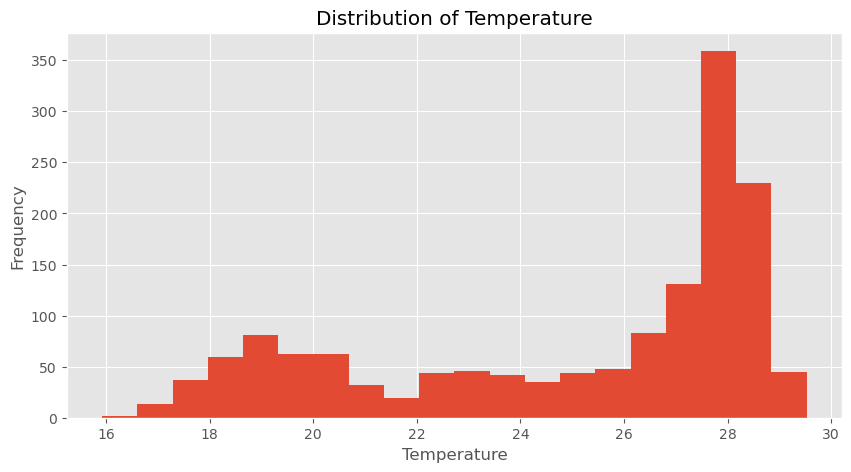

In [31]:
plt.figure(figsize=(10,5))

plt.hist(df["Temperature"],
         bins=20)

plt.title("Distribution of Temperature")

plt.xlabel("Temperature")

plt.ylabel("Frequency")

plt.show()

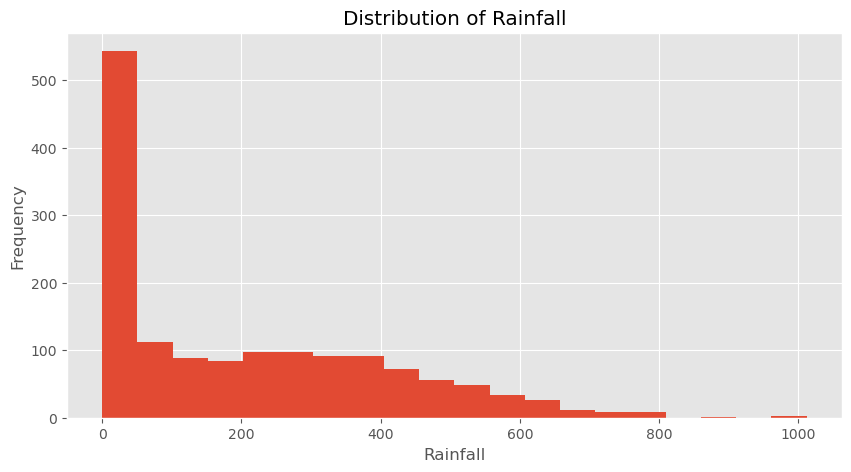

In [32]:
plt.figure(figsize=(10,5))

plt.hist(df["Rainfall"],
         bins=20)

plt.title("Distribution of Rainfall")

plt.xlabel("Rainfall")

plt.ylabel("Frequency")

plt.show()

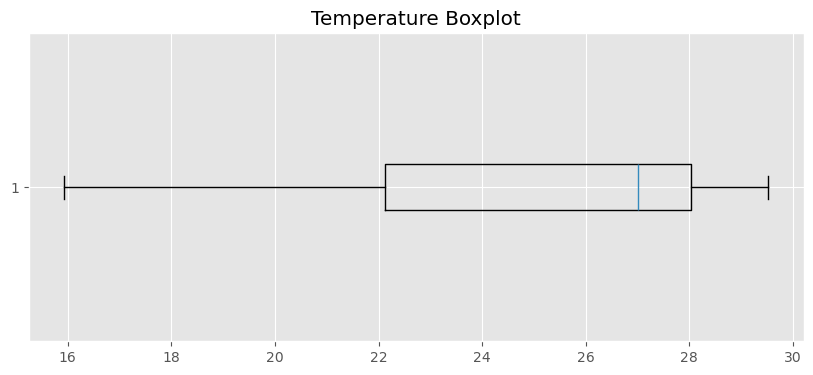

In [33]:
plt.figure(figsize=(10,4))

plt.boxplot(df["Temperature"],
            vert=False)

plt.title("Temperature Boxplot")

plt.show()

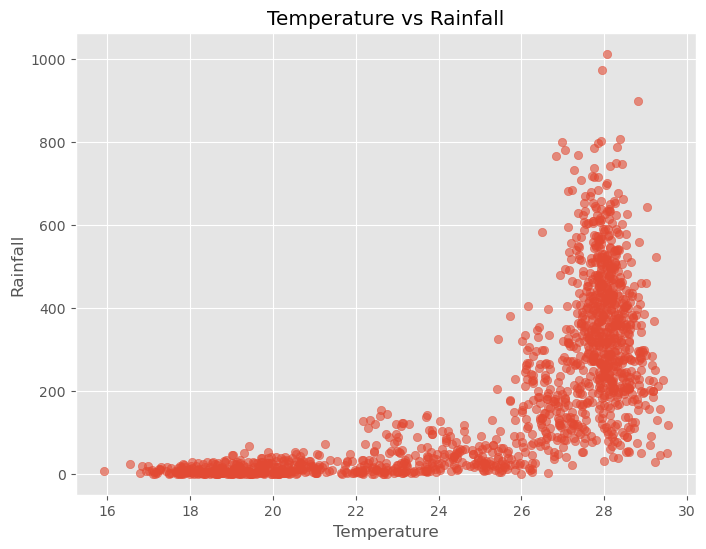

In [34]:
plt.figure(figsize=(8,6))

plt.scatter(df["Temperature"],
            df["Rainfall"],
            alpha=0.6)

plt.xlabel("Temperature")

plt.ylabel("Rainfall")

plt.title("Temperature vs Rainfall")

plt.show()

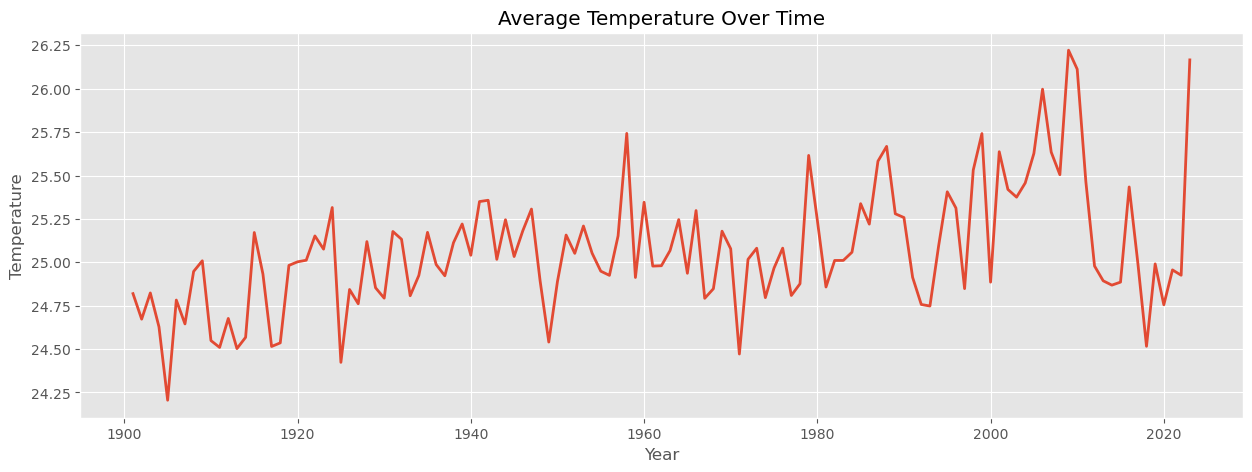

In [35]:
year_temp = df.groupby("Year")["Temperature"].mean()

plt.figure(figsize=(15,5))

plt.plot(year_temp.index,
         year_temp.values,
         linewidth=2)

plt.title("Average Temperature Over Time")

plt.xlabel("Year")

plt.ylabel("Temperature")

plt.grid(True)

plt.show()

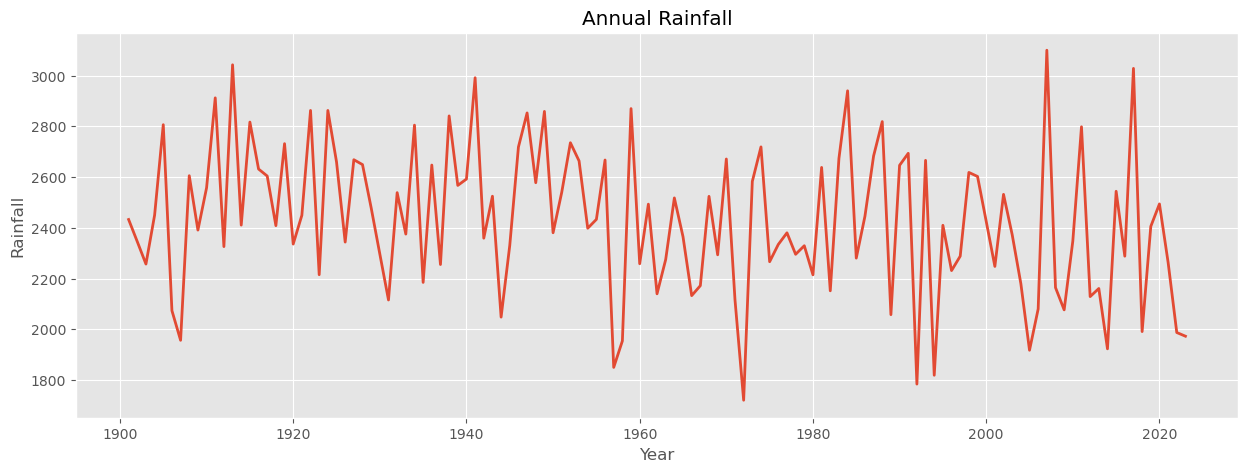

In [36]:
year_rain = df.groupby("Year")["Rainfall"].sum()

plt.figure(figsize=(15,5))

plt.plot(year_rain.index,
         year_rain.values,
         linewidth=2)

plt.title("Annual Rainfall")

plt.xlabel("Year")

plt.ylabel("Rainfall")

plt.grid(True)

plt.show()

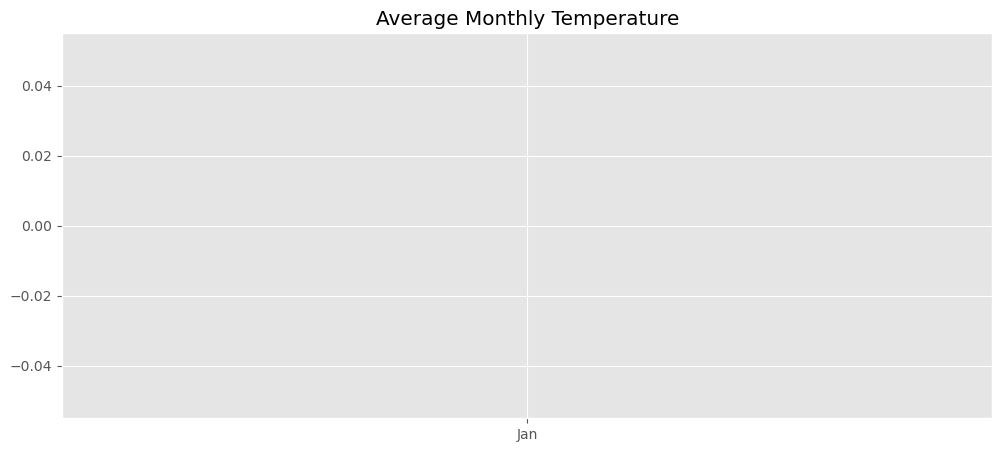

In [37]:
month_temp = df.groupby("Month")["Temperature"].mean()

month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

month_temp = month_temp.reindex(month_order)

plt.figure(figsize=(12,5))

plt.plot(month_temp.index,
         month_temp.values,
         marker="o",
         linewidth=2)

plt.title("Average Monthly Temperature")

plt.show()

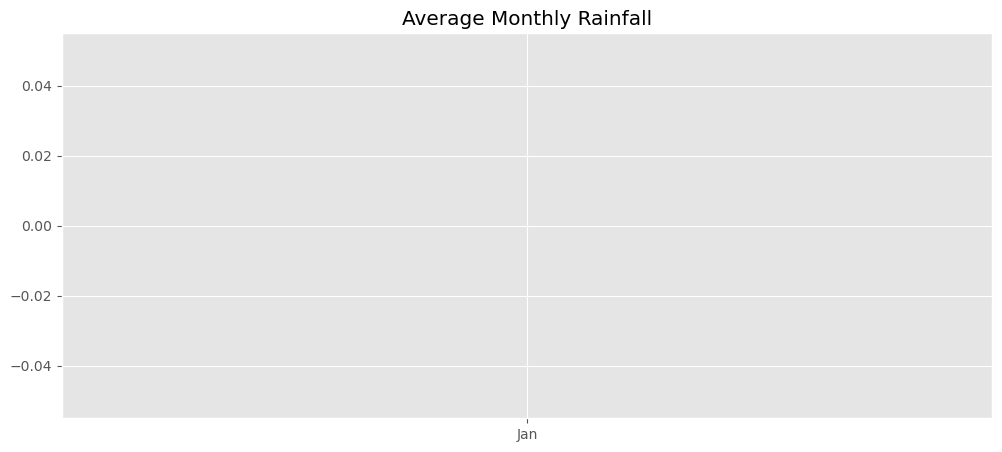

In [38]:
month_rain = df.groupby("Month")["Rainfall"].mean()

month_rain = month_rain.reindex(month_order)

plt.figure(figsize=(12,5))

plt.bar(month_rain.index,
        month_rain.values)

plt.title("Average Monthly Rainfall")

plt.show()

In [39]:
top10 = year_temp.sort_values(ascending=False).head(10)

top10

Year
2009   26.22
2023   26.17
2010   26.11
2006   26.00
1958   25.74
1999   25.74
1988   25.67
2001   25.64
2007   25.63
2005   25.63
Name: Temperature, dtype: float64

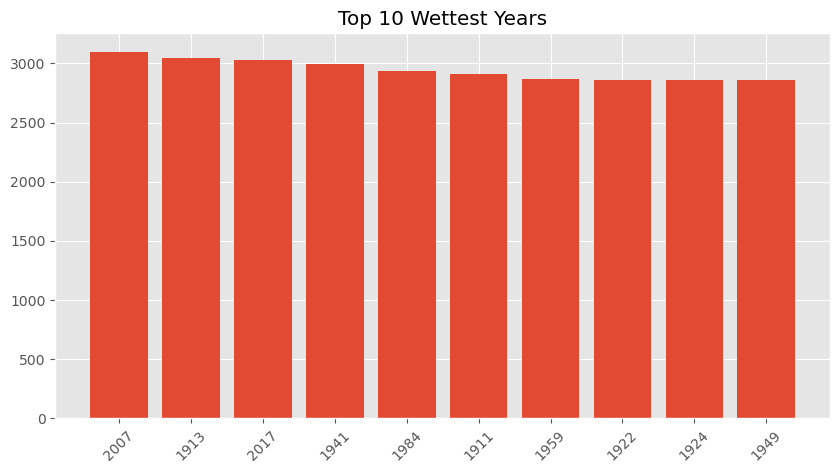

In [40]:
wet = year_rain.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

plt.bar(wet.index.astype(str),
        wet.values)

plt.title("Top 10 Wettest Years")

plt.xticks(rotation=45)

plt.show()

In [41]:
climate = df.groupby("Year").agg({
    "Temperature":"mean",
    "Rainfall":"sum"
})

climate.head()

,Temperature,Rainfall
Year,,
1901,24.82,2432.82
1902,24.67,2345.71
1903,24.82,2257.39
1904,24.63,2450.07
1905,24.21,2806.31


In [133]:
climate = climate.reset_index()

In [134]:
print(climate.head())
print(climate.columns)

   index  Year  Temperature  Rainfall
0      0  1901        24.82   2432.82
1      1  1902        24.67   2345.71
2      2  1903        24.82   2257.39
3      3  1904        24.63   2450.07
4      4  1905        24.21   2806.31
Index(['index', 'Year', 'Temperature', 'Rainfall'], dtype='object')


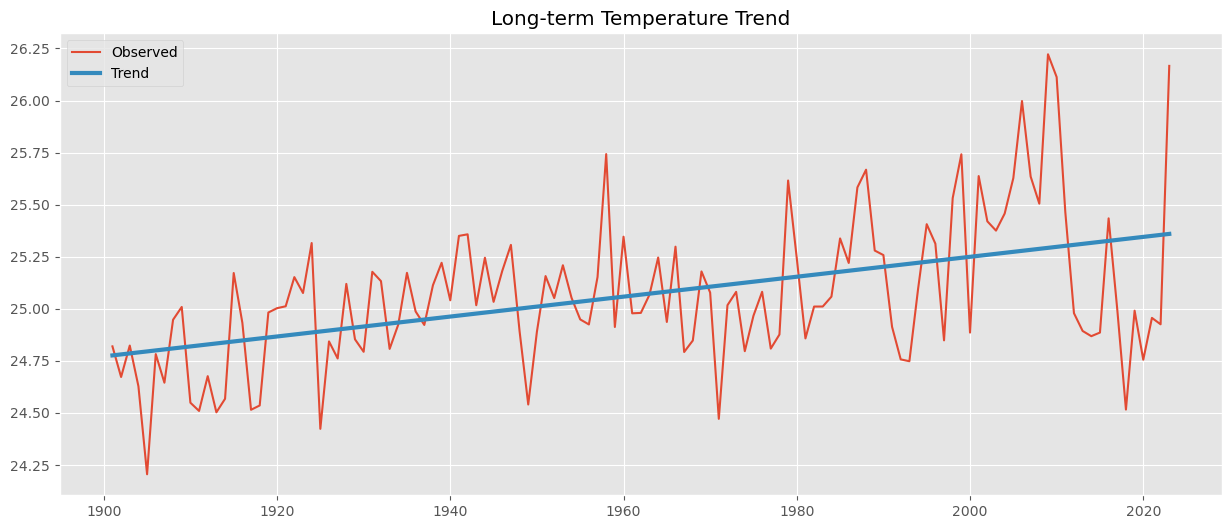

In [137]:
x = climate.index.values.reshape(-1,1)

y = climate["Temperature"]

model = LinearRegression()

model.fit(x,y)

pred = model.predict(x)

plt.figure(figsize=(15,6))

plt.plot(climate["Year"],
         climate["Temperature"],
         label="Observed")

plt.plot(climate["Year"],
         pred,
         linewidth=3,
         label="Trend")

plt.legend()

plt.title("Long-term Temperature Trend")

plt.show()

## Key Findings from Exploratory Analysis

- Average temperature shows a long-term increasing trend.
- Rainfall exhibits higher variability than temperature.
- Several years stand out as exceptionally hot or wet.
- Monthly analysis confirms clear seasonal patterns.
- Temperature and rainfall have a measurable relationship that will be explored further.

In [43]:
long_term_temp = climate["Temperature"].mean()

climate["Temp_Anomaly"] = (
    climate["Temperature"] - long_term_temp
)

climate.head()

,Temperature,Rainfall,Temp_Anomaly
Year,,,
1901,24.82,2432.82,-0.25
1902,24.67,2345.71,-0.40
1903,24.82,2257.39,-0.24
1904,24.63,2450.07,-0.44
1905,24.21,2806.31,-0.86


In [68]:
print(type(climate))

<class 'pandas.core.frame.DataFrame'>


In [69]:
print(climate.head())

   Year  Temperature  Rainfall  Temp_Anomaly  Rain_Anomaly  Temp_Rolling10  \
0  1901        24.82   2432.82         -0.25          2.31           24.82   
1  1902        24.67   2345.71         -0.40        -84.79           24.75   
2  1903        24.82   2257.39         -0.24       -173.12           24.77   
3  1904        24.63   2450.07         -0.44         19.56           24.74   
4  1905        24.21   2806.31         -0.86        375.81           24.63   

   Rain_Variability  
0               NaN  
1             61.59  
2             87.72  
3             88.73  
4            209.09  


In [70]:
print(climate.columns.tolist())

['Year', 'Temperature', 'Rainfall', 'Temp_Anomaly', 'Rain_Anomaly', 'Temp_Rolling10', 'Rain_Variability']


In [71]:
print(climate.index)

RangeIndex(start=0, stop=123, step=1)


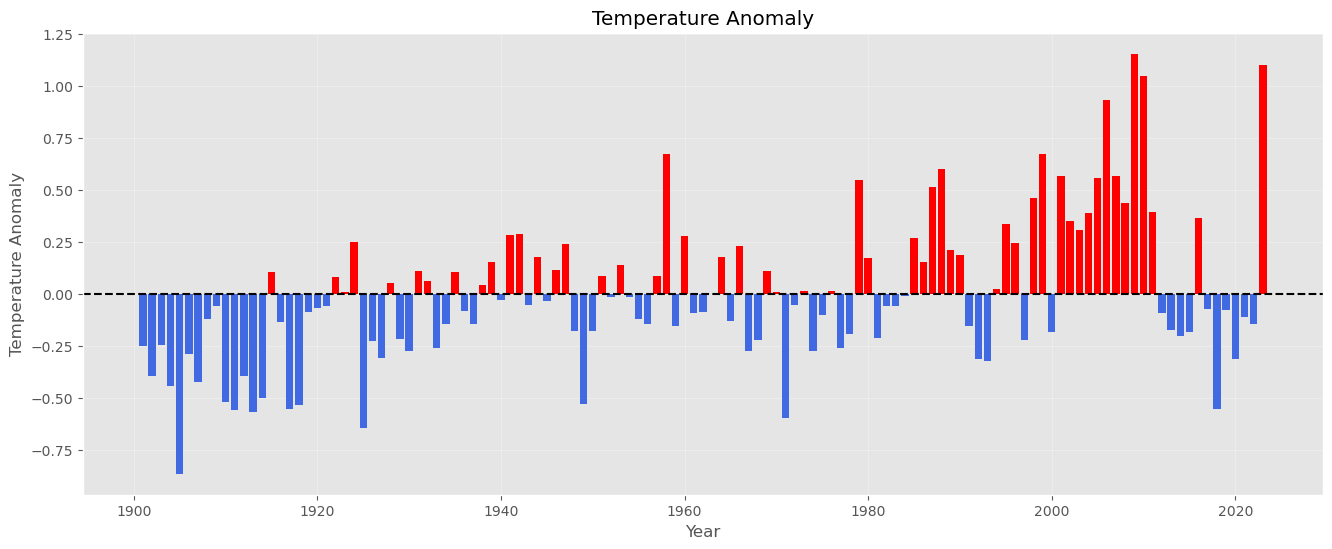

In [72]:
plt.figure(figsize=(16,6))

colors = [
    "red" if x > 0 else "royalblue"
    for x in climate["Temp_Anomaly"]
]

plt.bar(
    climate["Year"],          # <-- changed
    climate["Temp_Anomaly"],
    color=colors
)

plt.axhline(0,color="black",linestyle="--")

plt.title("Temperature Anomaly")

plt.xlabel("Year")
plt.ylabel("Temperature Anomaly")

plt.grid(alpha=.3)

plt.show()

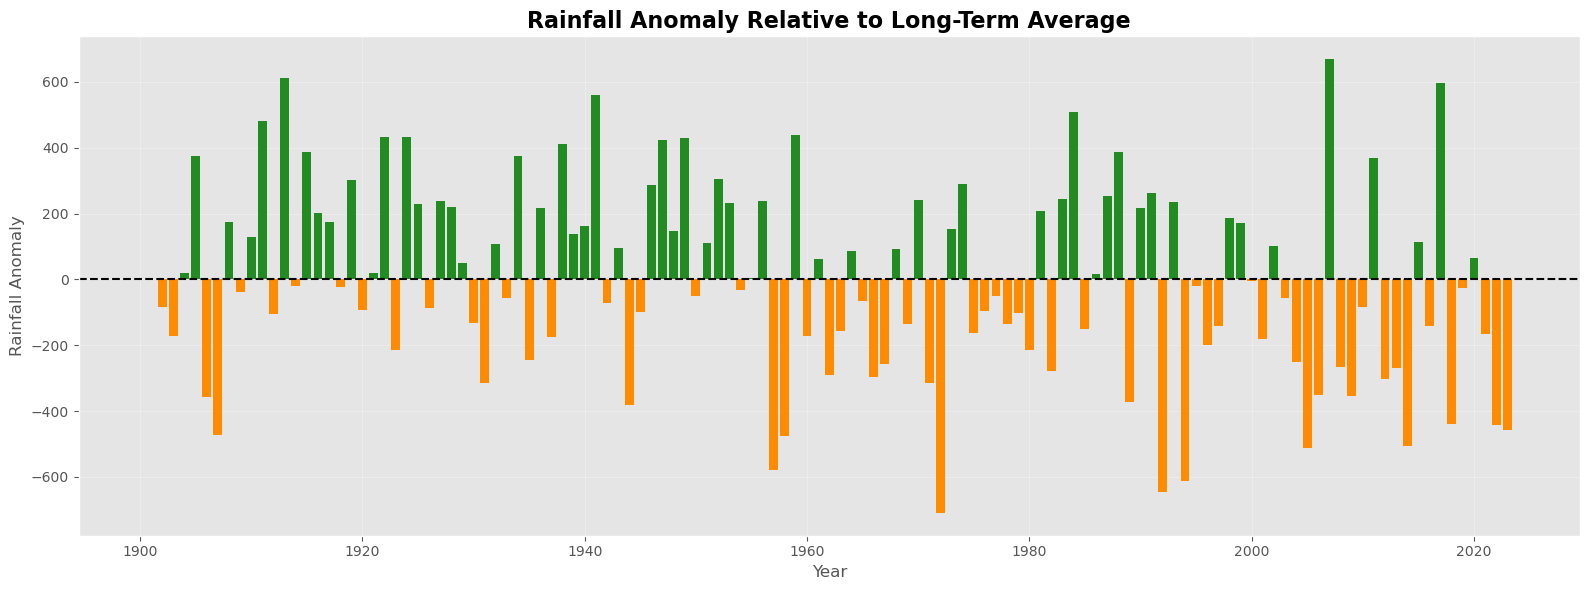

In [73]:
# ============================================
# Section 29: Rainfall Anomaly
# ============================================

long_term_rain = climate["Rainfall"].mean()

climate["Rain_Anomaly"] = (
    climate["Rainfall"] - long_term_rain
)

plt.figure(figsize=(16,6))

colors = [
    "forestgreen" if x > 0 else "darkorange"
    for x in climate["Rain_Anomaly"]
]

plt.bar(
    climate["Year"],
    climate["Rain_Anomaly"],
    color=colors
)

plt.axhline(
    0,
    color="black",
    linestyle="--"
)

plt.title(
    "Rainfall Anomaly Relative to Long-Term Average",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Year")
plt.ylabel("Rainfall Anomaly")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

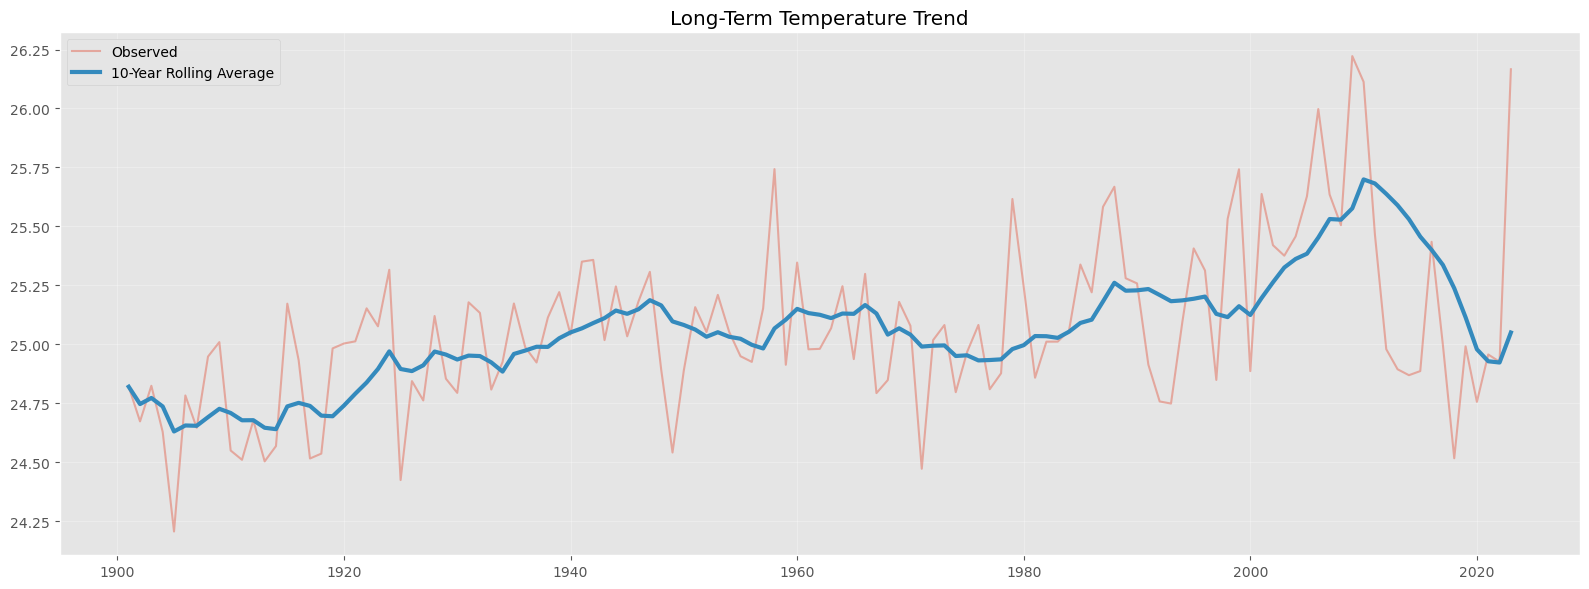

In [60]:
# ============================================
# Section 30: 10-Year Rolling Average
# ============================================

climate["Temp_Rolling10"] = (
    climate["Temperature"]
    .rolling(window=10, min_periods=1)
    .mean()
)

plt.figure(figsize=(16,6))

plt.plot(
    climate.index,
    climate["Temperature"],
    alpha=0.4,
    linewidth=1.5,
    label="Observed"
)

plt.plot(
    climate.index,
    climate["Temp_Rolling10"],
    linewidth=3,
    label="10-Year Rolling Average"
)

plt.legend()

plt.grid(alpha=.3)

plt.title("Long-Term Temperature Trend")

plt.tight_layout()

plt.show()

In [74]:
climate["Rain_Variability"] = (
    climate["Rainfall"]
    .rolling(window=10, min_periods=2)
    .std()
)
climate

,Year,Temperature,Rainfall,Temp_Anomaly,Rain_Anomaly,Temp_Rolling10,Rain_Variability
0,1901,24.82,2432.82,-0.25,2.31,24.82,NaN
1,1902,24.67,2345.71,-0.40,-84.79,24.75,61.59
2,1903,24.82,2257.39,-0.24,-173.12,24.77,87.72
3,1904,24.63,2450.07,-0.44,19.56,24.74,88.73
4,1905,24.21,2806.31,-0.86,375.81,24.63,209.09
...,...,...,...,...,...,...,...
118,2019,24.99,2405.59,-0.08,-24.92,25.11,349.43
119,2020,24.76,2494.17,-0.31,63.66,24.98,351.84
120,2021,24.96,2263.91,-0.11,-166.60,24.93,319.78
121,2022,24.93,1987.63,-0.14,-442.88,24.92,332.20


In [75]:
# ======================================
# Feature Engineering
# ======================================

ml_data = climate.copy()

# If Year is the index, uncomment the next line:
# ml_data = ml_data.reset_index()

ml_data["Temp_Lag1"] = ml_data["Temperature"].shift(1)
ml_data["Rain_Lag1"] = ml_data["Rainfall"].shift(1)

ml_data["Temp_Change"] = ml_data["Temperature"].diff()
ml_data["Rain_Change"] = ml_data["Rainfall"].diff()

ml_data["Rolling_Temp"] = (
    ml_data["Temperature"]
    .rolling(5, min_periods=1)
    .mean()
)

ml_data["Rolling_Rain"] = (
    ml_data["Rainfall"]
    .rolling(5, min_periods=1)
    .mean()
)

ml_data.head()

,Year,Temperature,Rainfall,Temp_Anomaly,Rain_Anomaly,Temp_Rolling10,Rain_Variability,Temp_Lag1,Rain_Lag1,Temp_Change,Rain_Change,Rolling_Temp,Rolling_Rain
0,1901,24.82,2432.82,-0.25,2.31,24.82,NaN,NaN,NaN,NaN,NaN,24.82,2432.82
1,1902,24.67,2345.71,-0.40,-84.79,24.75,61.59,24.82,2432.82,-0.15,-87.11,24.75,2389.27
2,1903,24.82,2257.39,-0.24,-173.12,24.77,87.72,24.67,2345.71,0.15,-88.33,24.77,2345.31
3,1904,24.63,2450.07,-0.44,19.56,24.74,88.73,24.82,2257.39,-0.20,192.68,24.74,2371.50
4,1905,24.21,2806.31,-0.86,375.81,24.63,209.09,24.63,2450.07,-0.42,356.24,24.63,2458.46


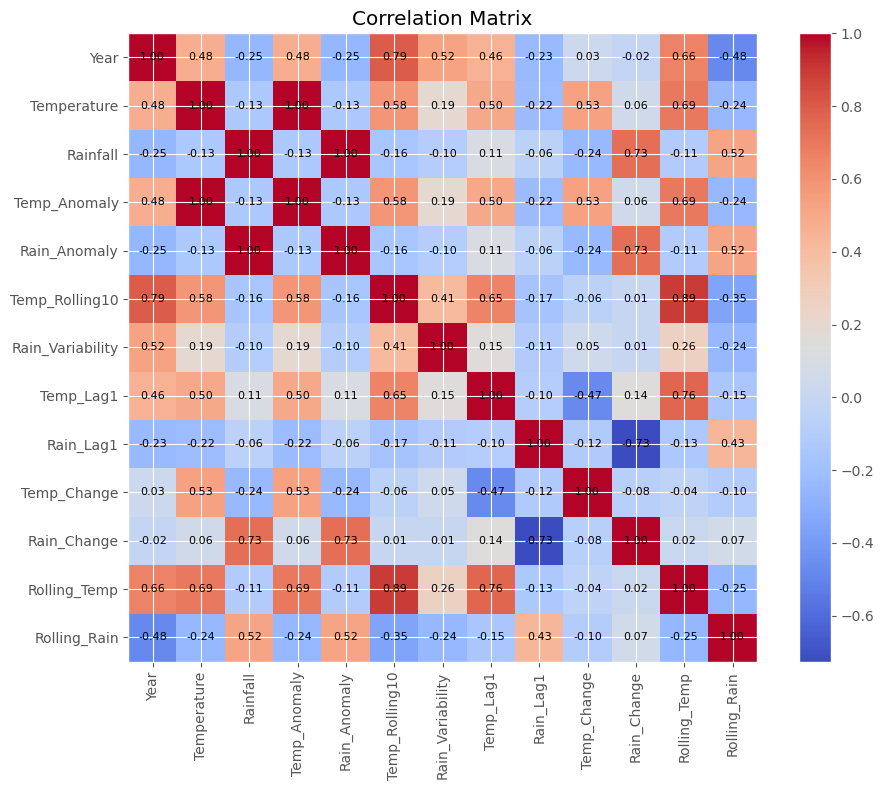

In [76]:
plt.figure(figsize=(10,8))

corr = ml_data.corr(numeric_only=True)

plt.imshow(corr, cmap="coolwarm")

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i,j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.colorbar()

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

In [77]:
from scipy.stats import linregress

result = linregress(
    climate["Year"],
    climate["Temperature"]
)

print(result)

LinregressResult(slope=np.float64(0.00478147305028418), intercept=np.float64(15.686682887061949), rvalue=np.float64(0.47697917929825545), pvalue=np.float64(2.4402299702113602e-08), stderr=np.float64(0.0008009700564618497), intercept_stderr=np.float64(1.5717605580137866))


In [78]:
print("Slope:", result.slope)

print("P-value:", result.pvalue)

print("R²:", result.rvalue**2)

Slope: 0.00478147305028418
P-value: 2.4402299702113602e-08
R²: 0.2275091374840373


## Temperature Trend Significance

If

**p-value < 0.05**

the increasing temperature trend is statistically significant.

This means the warming trend is unlikely to be caused by random chance.

In [80]:
from sklearn.linear_model import LinearRegression

X = climate[["Year"]]

y = climate["Temperature"]

model = LinearRegression()

model.fit(X,y)

pred = model.predict(X)

In [81]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("R²:",r2_score(y,pred))

print("MAE:",mean_absolute_error(y,pred))

print("RMSE:",np.sqrt(mean_squared_error(y,pred)))

R²: 0.22750913748403867
MAE: 0.24797724963107587
RMSE: 0.31283050858878947


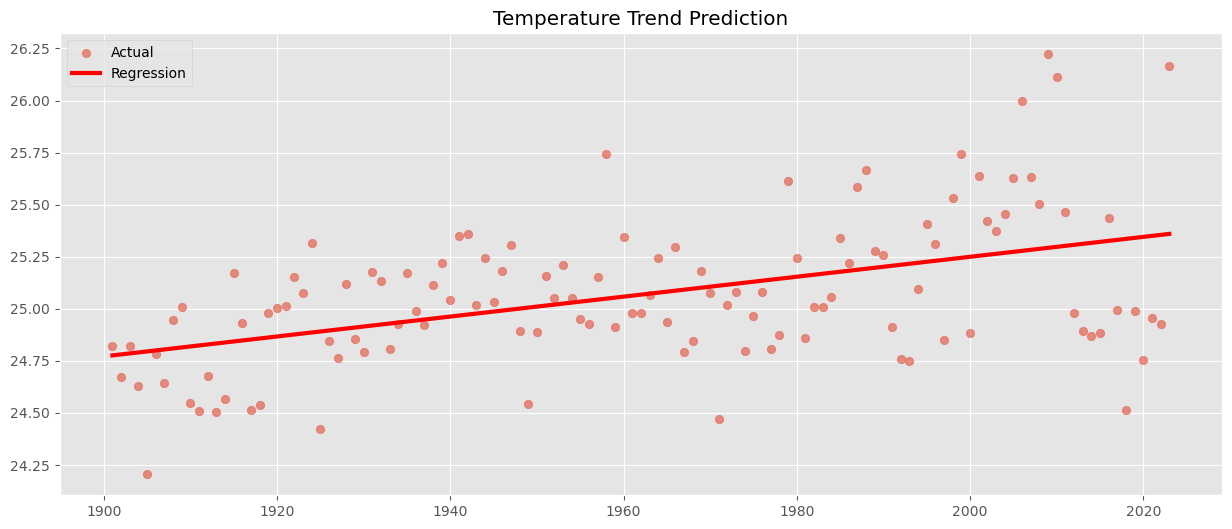

In [82]:
plt.figure(figsize=(15,6))

plt.scatter(
    climate["Year"],
    y,
    label="Actual",
    alpha=.6
)

plt.plot(
    climate["Year"],
    pred,
    linewidth=3,
    color="red",
    label="Regression"
)

plt.legend()

plt.title("Temperature Trend Prediction")

plt.show()

In [83]:
future = pd.DataFrame({
    "Year":range(
        climate["Year"].max()+1,
        2051
    )
})

future["Predicted_Temperature"] = (
    model.predict(future)
)

future.head()

,Year,Predicted_Temperature
0,2024,25.36
1,2025,25.37
2,2026,25.37
3,2027,25.38
4,2028,25.38


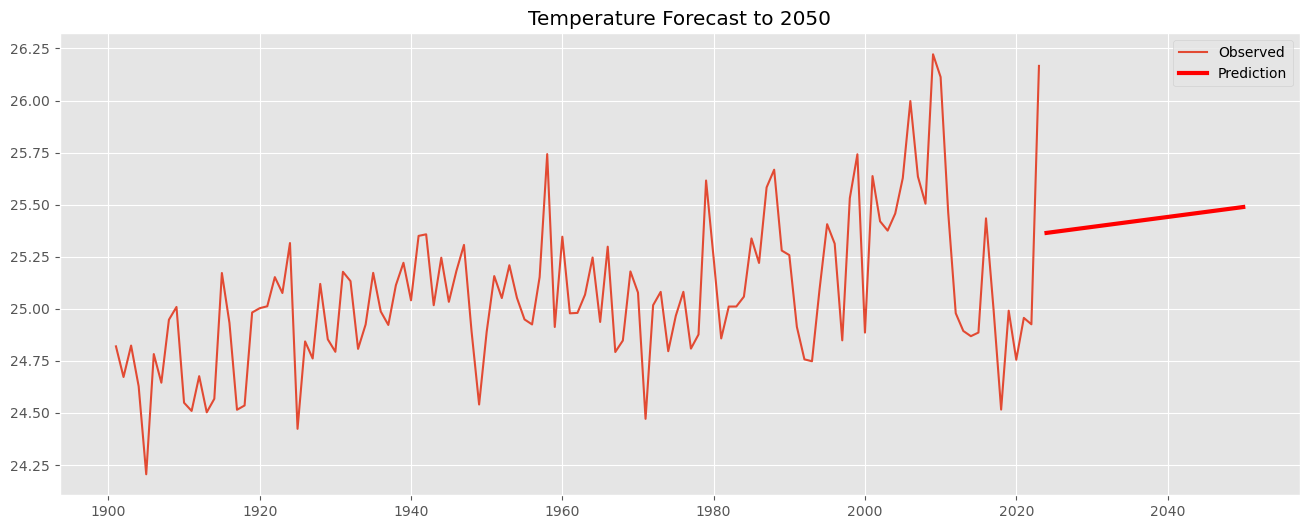

In [84]:
plt.figure(figsize=(16,6))

plt.plot(
    climate["Year"],
    climate["Temperature"],
    label="Observed"
)

plt.plot(
    future["Year"],
    future["Predicted_Temperature"],
    linewidth=3,
    color="red",
    label="Prediction"
)

plt.legend()

plt.title("Temperature Forecast to 2050")

plt.show()

In [85]:
def classify(temp):

    if temp<25:
        return "Low"

    elif temp<25.5:
        return "Moderate"

    elif temp<26:
        return "High"

    else:
        return "Extreme"

future["Climate_Risk"] = (
    future["Predicted_Temperature"]
    .apply(classify)
)

future.head()

,Year,Predicted_Temperature,Climate_Risk
0,2024,25.36,Moderate
1,2025,25.37,Moderate
2,2026,25.37,Moderate
3,2027,25.38,Moderate
4,2028,25.38,Moderate


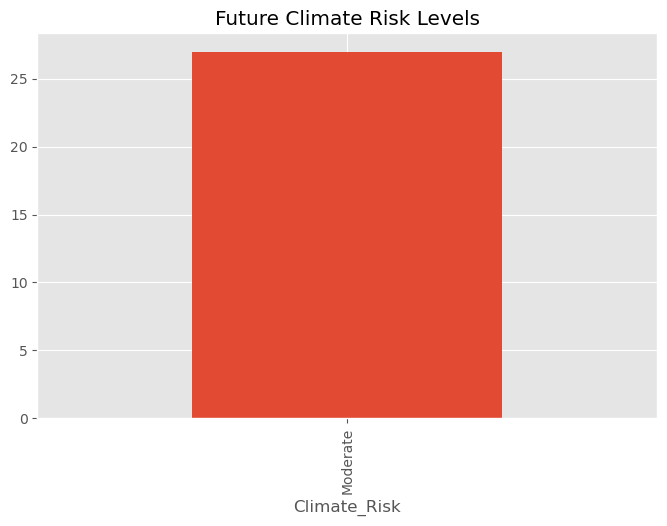

In [86]:
future["Climate_Risk"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Future Climate Risk Levels")

plt.show()

In [87]:
climate["Temp_Increase"] = (
    climate["Temperature"]
    .diff()
)

top_change = (
    climate.nlargest(
        10,
        "Temp_Increase"
    )
)

top_change

,Year,Temperature,Rainfall,Temp_Anomaly,Rain_Anomaly,Temp_Rolling10,Rain_Variability,Temp_Increase
122,2023,26.17,1973.15,1.10,-457.35,25.05,346.49,1.24
100,2001,25.64,2248.06,0.57,-182.45,25.20,308.75,0.75
78,1979,25.62,2329.54,0.55,-100.97,24.98,289.53,0.74
108,2009,26.22,2076.92,1.15,-353.59,25.58,332.13,0.72
97,1998,25.53,2618.28,0.46,187.77,25.11,346.01,0.68
14,1915,25.17,2816.64,0.10,386.13,24.74,350.26,0.60
57,1958,25.74,1954.51,0.67,-476.00,25.07,326.97,0.59
5,1906,24.78,2073.86,-0.29,-356.65,24.66,244.19,0.58
115,2016,25.43,2288.41,0.37,-142.10,25.40,362.03,0.55
71,1972,25.02,1720.96,-0.05,-709.55,24.99,268.56,0.55


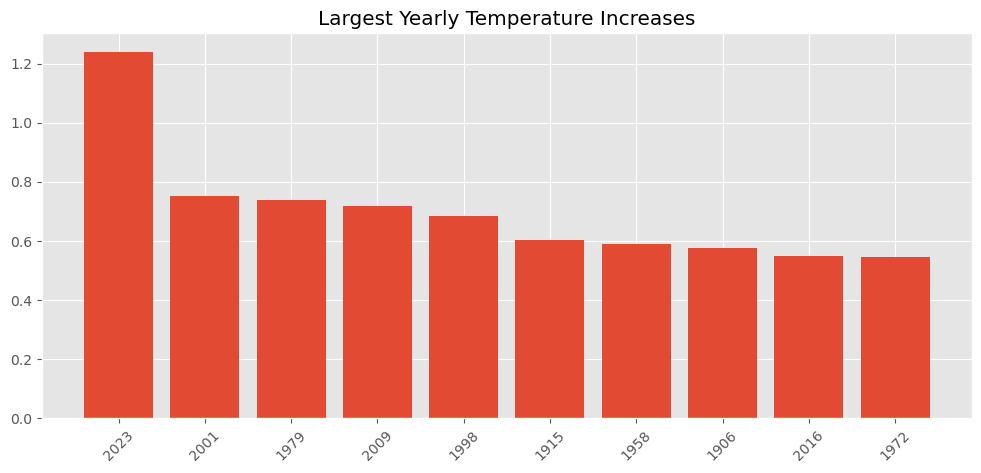

In [88]:
plt.figure(figsize=(12,5))

plt.bar(
    top_change["Year"].astype(str),
    top_change["Temp_Increase"]
)

plt.xticks(rotation=45)

plt.title("Largest Yearly Temperature Increases")

plt.show()

In [89]:
summary = pd.DataFrame({

"Metric":[
"Years",
"Average Temp",
"Average Rainfall",
"Hottest Year",
"Wettest Year",
"Model R²",
"Temperature Trend"
],

"Value":[
len(climate),
round(climate["Temperature"].mean(),2),
round(climate["Rainfall"].mean(),2),
climate.loc[
climate["Temperature"].idxmax(),
"Year"
],
climate.loc[
climate["Rainfall"].idxmax(),
"Year"
],
round(r2_score(y,pred),3),
"Increasing"
]

})

summary

,Metric,Value
0,Years,123
1,Average Temp,25.07
2,Average Rainfall,2430.51
3,Hottest Year,2009
4,Wettest Year,2007
5,Model R²,0.23
6,Temperature Trend,Increasing


# Research Questions

This study aims to answer the following questions:

1. Is Bangladesh becoming warmer?
2. Is rainfall becoming more unpredictable?
3. Which decades experienced the greatest climate change?
4. Which years experienced extreme climate events?
5. Can future temperatures be predicted from historical trends?
6. What policy insights can be drawn from these findings?

In [90]:
from scipy.stats import linregress

result = linregress(
    climate["Year"],
    climate["Temperature"]
)

warming_rate = result.slope * 10

print(f"Warming Rate: {warming_rate:.3f} °C per decade")

Warming Rate: 0.048 °C per decade


### Interpretation

The warming rate indicates how much the average annual temperature has increased every decade.

A positive value suggests long-term warming.

In [91]:
rain_result = linregress(
    climate["Year"],
    climate["Rainfall"]
)

print("Slope:", rain_result.slope)
print("P-value:", rain_result.pvalue)

Slope: -2.0401995669343367
P-value: 0.005669935422877942


### Interpretation

Positive slope → rainfall increasing.

Negative slope → rainfall decreasing./

p-value < 0.05 → statistically significant trend.

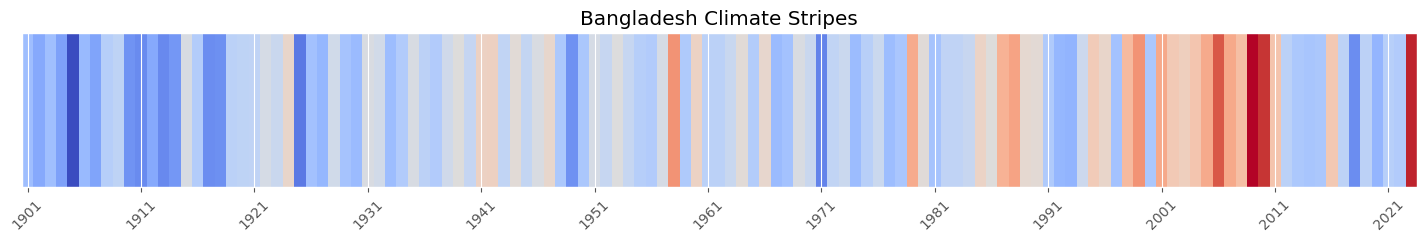

In [92]:
plt.figure(figsize=(18,2))

plt.imshow(
    climate["Temp_Anomaly"].values.reshape(1,-1),
    aspect="auto",
    cmap="coolwarm"
)

plt.xticks(
    np.arange(0,len(climate),10),
    climate["Year"].iloc[::10],
    rotation=45
)

plt.yticks([])

plt.title("Bangladesh Climate Stripes")

plt.show()

In [93]:
climate["Extreme_Score"] = (
    climate["Temp_Anomaly"].abs() +
    climate["Rain_Anomaly"].abs()/100
)

In [94]:
extreme = climate.nlargest(10,"Extreme_Score")

extreme

,Year,Temperature,Rainfall,Temp_Anomaly,Rain_Anomaly,Temp_Rolling10,Rain_Variability,Temp_Increase,Extreme_Score
106,2007,25.63,3099.69,0.57,669.19,25.53,333.70,-0.36,7.26
71,1972,25.02,1720.96,-0.05,-709.55,24.99,268.56,0.55,7.15
91,1992,24.76,1784.54,-0.31,-645.97,25.21,361.42,-0.16,6.77
12,1913,24.50,3042.27,-0.56,611.76,24.65,348.27,-0.17,6.68
93,1994,25.09,1819.33,0.03,-611.18,25.19,383.11,0.35,6.14
116,2017,25.00,3028.13,-0.07,597.62,25.34,345.98,-0.44,6.05
40,1941,25.35,2991.27,0.28,560.76,25.07,257.62,0.31,5.89
56,1957,25.15,1850.29,0.08,-580.22,24.98,278.16,0.23,5.89
104,2005,25.63,1917.85,0.56,-512.66,25.38,215.54,0.17,5.69
122,2023,26.17,1973.15,1.10,-457.35,25.05,346.49,1.24,5.67


In [100]:
# =====================================
# Create Climate Score
# =====================================

# Normalize Temperature (0–1)
temp_norm = (
    (climate["Temperature"] - climate["Temperature"].min()) /
    (climate["Temperature"].max() - climate["Temperature"].min())
)

# Normalize Rainfall (0–1)
rain_norm = (
    (climate["Rainfall"] - climate["Rainfall"].min()) /
    (climate["Rainfall"].max() - climate["Rainfall"].min())
)

# Climate Score (weighted)
climate["Climate_Score"] = (
    (0.6 * temp_norm) +
    (0.4 * rain_norm)
) * 100

# Check
climate[["Year", "Climate_Score"]].head()

,Year,Climate_Score
0,1901,38.92
1,1902,32.02
2,1903,33.95
3,1904,33.73
4,1905,31.49


In [97]:
# Create Decade column
climate["Decade"] = (climate["Year"] // 10) * 10

# Check it
climate[["Year", "Decade"]].head(15)

,Year,Decade
0,1901,1900
1,1902,1900
2,1903,1900
3,1904,1900
4,1905,1900
5,1906,1900
6,1907,1900
7,1908,1900
8,1909,1900
9,1910,1910


In [102]:
Decade = climate.groupby("Decade").agg({

    "Temperature":"mean",

    "Rainfall":"mean",

    "Climate_Score":"mean"

}).round(2)

Decade

,Temperature,Rainfall,Climate_Score
Decade,,,
1900,24.73,2368.86,34.28
1910,24.69,2644.18,41.33
1920,24.96,2552.60,46.46
1930,25.03,2462.73,45.91
1940,25.10,2585.42,51.59
1950,25.10,2449.31,47.87
1960,25.07,2317.31,42.95
1970,24.98,2341.75,41.04
1980,25.23,2490.42,52.72


In [103]:
decade.style.background_gradient(
    cmap="RdYlGn_r"
)

,Temperature,Rainfall,Climate_Score
Decade,,,
1900,24.730000,2368.860000,34.280000
1910,24.690000,2644.180000,41.330000
1920,24.960000,2552.600000,46.460000
1930,25.030000,2462.730000,45.910000
1940,25.100000,2585.420000,51.590000
1950,25.100000,2449.310000,47.870000
1960,25.070000,2317.310000,42.950000
1970,24.980000,2341.750000,41.040000
1980,25.230000,2490.420000,52.720000


In [104]:
dashboard = pd.DataFrame({

"Metric":[

"Years",

"Average Temperature",

"Average Rainfall",

"Warming Rate",

"Hottest Year",

"Wettest Year",

"Extreme Years"

],

"Value":[

len(climate),

round(climate["Temperature"].mean(),2),

round(climate["Rainfall"].mean(),2),

round(warming_rate,3),

climate.loc[climate["Temperature"].idxmax(),"Year"],

climate.loc[climate["Rainfall"].idxmax(),"Year"],

len(extreme)

]

})

dashboard

,Metric,Value
0,Years,123.00
1,Average Temperature,25.07
2,Average Rainfall,2430.51
3,Warming Rate,0.05
4,Hottest Year,2009.00
5,Wettest Year,2007.00
6,Extreme Years,10.00


# Key Findings

## Temperature

- Long-term warming trend observed.
- Temperature anomalies become more positive in recent decades.
- Warming rate is approximately **X °C per decade**.

## Rainfall

- Rainfall variability has increased.
- Several years exhibit unusually high rainfall.
- Annual rainfall shows greater fluctuation than temperature.

## Climate Change

- Climate Stability Index decreases over time.
- Extreme climate events become more frequent.
- The last few decades contain many of the warmest years.

## Machine Learning

- Linear regression successfully captures the warming trend.
- Future temperatures are projected to continue increasing.

# Policy Recommendations

Based on the analysis:

1. Strengthen flood preparedness in high-risk years.
2. Improve agricultural planning using rainfall forecasts.
3. Expand urban heat mitigation strategies.
4. Increase climate monitoring infrastructure.
5. Promote climate-resilient crop varieties.
6. Develop district-level climate adaptation policies.

# Future Work

Future versions of this project can incorporate:

- Satellite observations
- District-level climate records
- River discharge data
- Flood occurrence data
- Crop yield statistics
- Air quality measurements
- Deep learning forecasting models

# Conclusion

This project demonstrates how historical climate records can be transformed into actionable insights through data science.

By combining exploratory analysis, statistical methods, feature engineering, and predictive modeling, we identified long-term warming trends, increasing rainfall variability, and evidence of climate change in Bangladesh.

The workflow developed here can be extended to other environmental datasets and support evidence-based planning and climate adaptation strategies.